<Axes: xlabel='Hogwarts House', ylabel='count'>

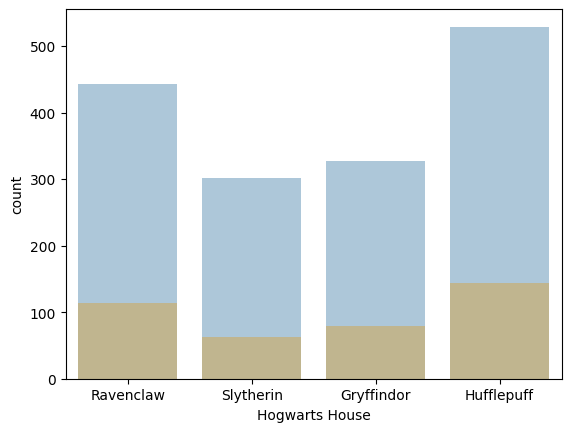

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data= pd.read_csv("../datasets/dataset_train.csv")
pred = pd.read_csv("../prediction.csv")

target="Hogwarts House"

labels = data[target].unique().tolist()

# X = train[""]

fig, ax = plt.subplots()

sns.countplot(x=target, data=data, alpha=0.4,ax=ax)
sns.countplot(x=target, data=pred, alpha=0.4, color="orange",ax=ax)

# plt.show()

/tmp/ipykernel_28374/804366592.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


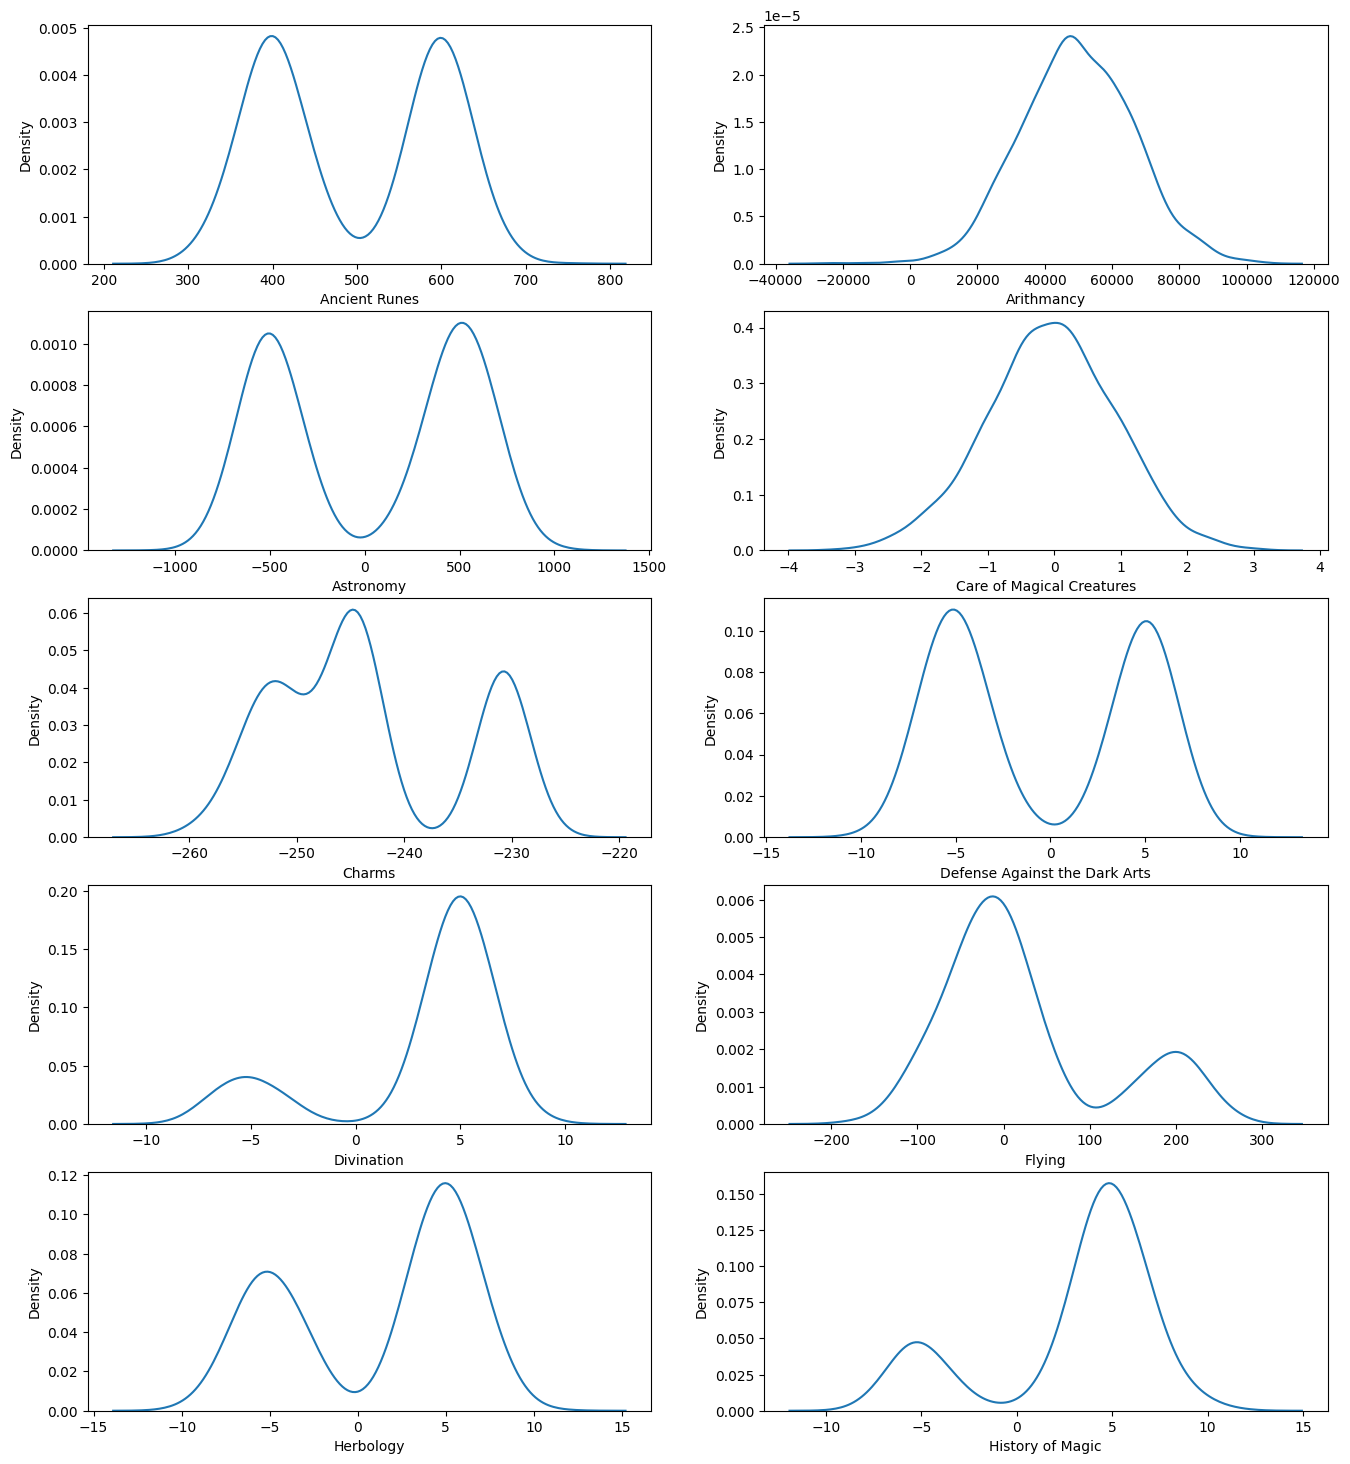

In [68]:
cols_to_drop = ["Index", "First Name", "Last Name", "Birthday"]
data = data[data.columns.difference(cols_to_drop).tolist()]  # type: ignore

categorical_features = ["Best Hand"]
num_features = data.columns.difference(categorical_features).tolist() # type: ignore

fig, axes = plt.subplots(5,2, figsize=(16,18))
for ax, col in zip(axes.flat, num_features):
    sns.kdeplot(data=data[col],ax=ax) # type: ignore


fig.show()

In [69]:
from sklearn.model_selection import train_test_split
from logreg_predict import predict
import joblib

X = data.drop(columns=target)
y = data[target]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, stratify=y, test_size=0.2)



In [70]:
# X_train["Best Hand"] = X_train["Best Hand"].map({"Left": 0, "Right": 1})  # type: ignore

# drop noise + target
cols_to_drop = ["Index", "First Name", "Last Name", "Birthday"]
X_train = X_train[X_train.columns.difference(cols_to_drop).tolist()]  # type: ignore

categorical_features = ["Best Hand"]
num_features = X_train.columns.difference(categorical_features).tolist()

# # handle na
# X_train[num_features] = X_train[num_features].fillna(X_train[num_features].median())  # type: ignore
# X_train[categorical_features] = X_train[categorical_features].fillna(X_train[categorical_features].mode().iloc[0])  # type: ignore

# X_valid[num_features] = X_valid[num_features].fillna(X_valid[num_features].median())  # type: ignore
# X_valid[categorical_features] = X_valid[categorical_features].fillna(X_valid[categorical_features].mode().iloc[0])  # type: ignore

In [71]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

num_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler())
    ])

cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder())
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, categorical_features)
], remainder="passthrough")

import numpy as np

X_train_proc: np.ndarray = preprocessor.fit_transform(X_train)
X_valid_proc  = preprocessor.transform(X_valid)

dff = pd.DataFrame(X_valid_proc, columns=preprocessor.get_feature_names_out())
dff


,num__Ancient Runes,num__Arithmancy,num__Astronomy,num__Care of Magical Creatures,num__Charms,num__Defense Against the Dark Arts,num__Divination,num__Flying,num__Herbology,num__History of Magic,num__Muggle Studies,num__Potions,num__Transfiguration,cat__Best Hand
0,-0.985987,-0.467356,1.084280,-0.807612,-0.093409,-1.086796,0.075041,-0.015137,1.144430,0.748678,-0.152415,-0.420111,-0.078431,0.0
1,-1.385953,-0.948714,1.086541,-0.116531,-0.110157,-1.089054,0.099657,-0.330514,0.934005,0.970142,0.121839,-0.720723,-0.163520,1.0
2,1.611349,1.809429,-1.081430,0.287175,1.647398,1.076066,0.622682,-0.289003,1.307495,0.945986,1.342013,0.435855,0.111551,0.0
3,-1.692761,-0.438487,1.189803,0.411539,-0.274485,-1.192180,0.171798,-0.036866,1.339144,-0.033550,-0.135623,-2.129934,0.134512,0.0
4,-1.876428,-0.805826,0.645959,1.646534,0.110864,-0.649051,0.150351,-0.654398,1.190516,0.319279,0.005598,-1.679393,0.040968,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,-1.097270,0.649369,-1.035826,1.417537,-0.892147,-0.424812,-2.007309,-1.230624,-1.280360,0.533630,-0.694453,0.916454,0.522951,1.0
316,0.218704,0.917094,0.890643,0.522882,-0.148098,-0.893414,0.762334,0.564062,0.758537,-0.571621,-1.445115,0.542577,0.932490,0.0
317,0.821918,-2.044957,-0.929357,-1.131182,1.601387,0.924193,0.321199,0.205945,1.014005,0.657931,1.160374,1.309551,0.594312,1.0
318,0.791441,1.738015,-1.211627,0.515107,1.040350,1.206092,0.322905,-0.810395,0.307228,0.251616,1.705137,-0.973655,0.124686,1.0


In [72]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_valid_enc = le.transform(y_valid)

labels=le.classes_.tolist()


In [73]:
# from math import exp
import importlib
import ft_logistic_regression, config
importlib.reload(ft_logistic_regression)
importlib.reload(config)
from ft_logistic_regression import FtLogisticRegression
from config import MODEL_PATH

ft_lr = FtLogisticRegression()

ft_lr.fit(X_train_proc, y_train_enc)

joblib.dump(ft_lr, MODEL_PATH)

['../model/model.pkl']

(320,)


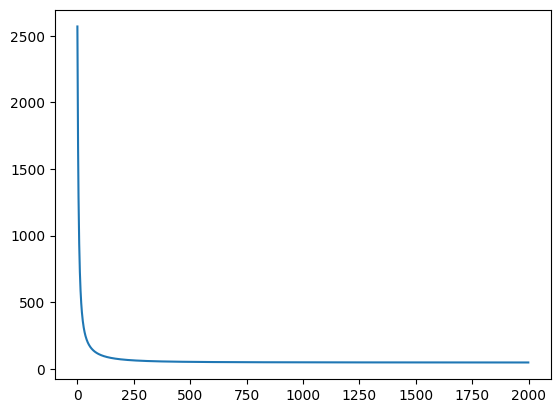

In [74]:


lr = joblib.load(MODEL_PATH)

ft_p = lr.predict(X_valid_proc)
print(ft_p.shape)
ft_p

lr.loss_

plt.plot(lr.loss_)


In [75]:
from sklearn.linear_model import LogisticRegression


lr = LogisticRegression()

lr.fit(X_train_proc, y_train_enc)

p = lr.predict(X_valid_proc)
print(p.shape)
p



(320,)


array([1, 1, 2, 1, 1, 0, 3, 0, 0, 1, 1, 2, 1, 1, 1, 3, 1, 2, 0, 2, 2, 1,
       1, 1, 0, 2, 1, 2, 2, 0, 2, 1, 0, 2, 2, 1, 2, 2, 0, 2, 3, 3, 1, 2,
       2, 2, 1, 1, 1, 2, 3, 2, 1, 1, 1, 2, 1, 3, 3, 3, 0, 2, 1, 1, 0, 0,
       3, 3, 0, 0, 2, 2, 1, 1, 3, 0, 0, 0, 3, 1, 1, 1, 2, 3, 2, 2, 0, 1,
       2, 3, 3, 2, 0, 0, 1, 2, 1, 1, 0, 0, 3, 2, 1, 1, 3, 0, 1, 3, 1, 0,
       3, 2, 1, 1, 3, 1, 1, 3, 1, 1, 3, 0, 3, 1, 1, 2, 2, 0, 3, 0, 1, 0,
       3, 3, 0, 0, 2, 1, 2, 0, 2, 1, 3, 2, 1, 1, 2, 0, 1, 2, 1, 2, 2, 1,
       1, 0, 1, 0, 1, 2, 2, 1, 1, 1, 3, 1, 1, 2, 1, 0, 2, 0, 2, 3, 1, 0,
       2, 2, 3, 1, 0, 1, 1, 1, 2, 1, 1, 1, 3, 3, 2, 0, 3, 2, 2, 2, 0, 1,
       3, 2, 3, 2, 1, 2, 0, 1, 3, 3, 1, 2, 1, 2, 2, 3, 1, 1, 3, 0, 1, 0,
       1, 0, 2, 0, 1, 1, 3, 0, 3, 2, 2, 1, 2, 3, 0, 0, 0, 3, 0, 2, 1, 1,
       1, 3, 2, 0, 0, 2, 0, 2, 3, 3, 3, 3, 3, 1, 3, 0, 1, 0, 1, 0, 2, 2,
       3, 2, 3, 1, 3, 1, 0, 2, 1, 1, 2, 3, 1, 1, 1, 3, 2, 0, 3, 0, 0, 2,
       2, 1, 0, 2, 2, 1, 1, 2, 1, 2, 0, 1, 1, 1, 1,

In [76]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
)
from sklearn.utils.multiclass import unique_labels

def evaluate(name, model, X_test, y_test):
    pred = model.predict(X_valid_proc)
    proba = model.predict_proba(X_valid_proc)
    cm = confusion_matrix(y_test, pred, normalize="true")
    cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    # cm_plot.plot()

    cr = classification_report(y_test, pred, target_names=labels)

    auc = roc_auc_score(y_test, proba, multi_class="ovr")
    precision = precision_score(y_test, pred, average="macro")

    print("AUC score: ", auc)
    print("Precision score: ", precision)
    print(cr)

evaluate("Log reg", lr, X_valid_proc, y_valid_enc)


AUC score:  0.9908376968865581
Precision score:  0.985752881426683
              precision    recall  f1-score   support

  Gryffindor       0.98      0.98      0.98        65
  Hufflepuff       0.99      1.00      1.00       106
   Ravenclaw       1.00      0.97      0.98        89
   Slytherin       0.97      1.00      0.98        60

    accuracy                           0.99       320
   macro avg       0.99      0.99      0.99       320
weighted avg       0.99      0.99      0.99       320



Text(0.5, 1.0, 'PR curve')

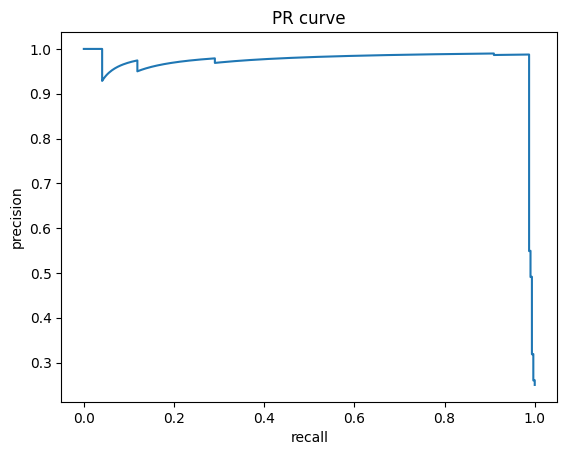

In [77]:
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

class_indices = le.classes_

proba = lr.predict_proba(X_valid_proc)
y_valid_bin = label_binarize(y_valid_enc, classes=range(len(class_indices)))

score = average_precision_score(y_valid_bin, proba, average="macro")


precision, recall, _ = precision_recall_curve(y_valid_bin.ravel(), proba.ravel())
plt.plot(recall, precision)

plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR curve")






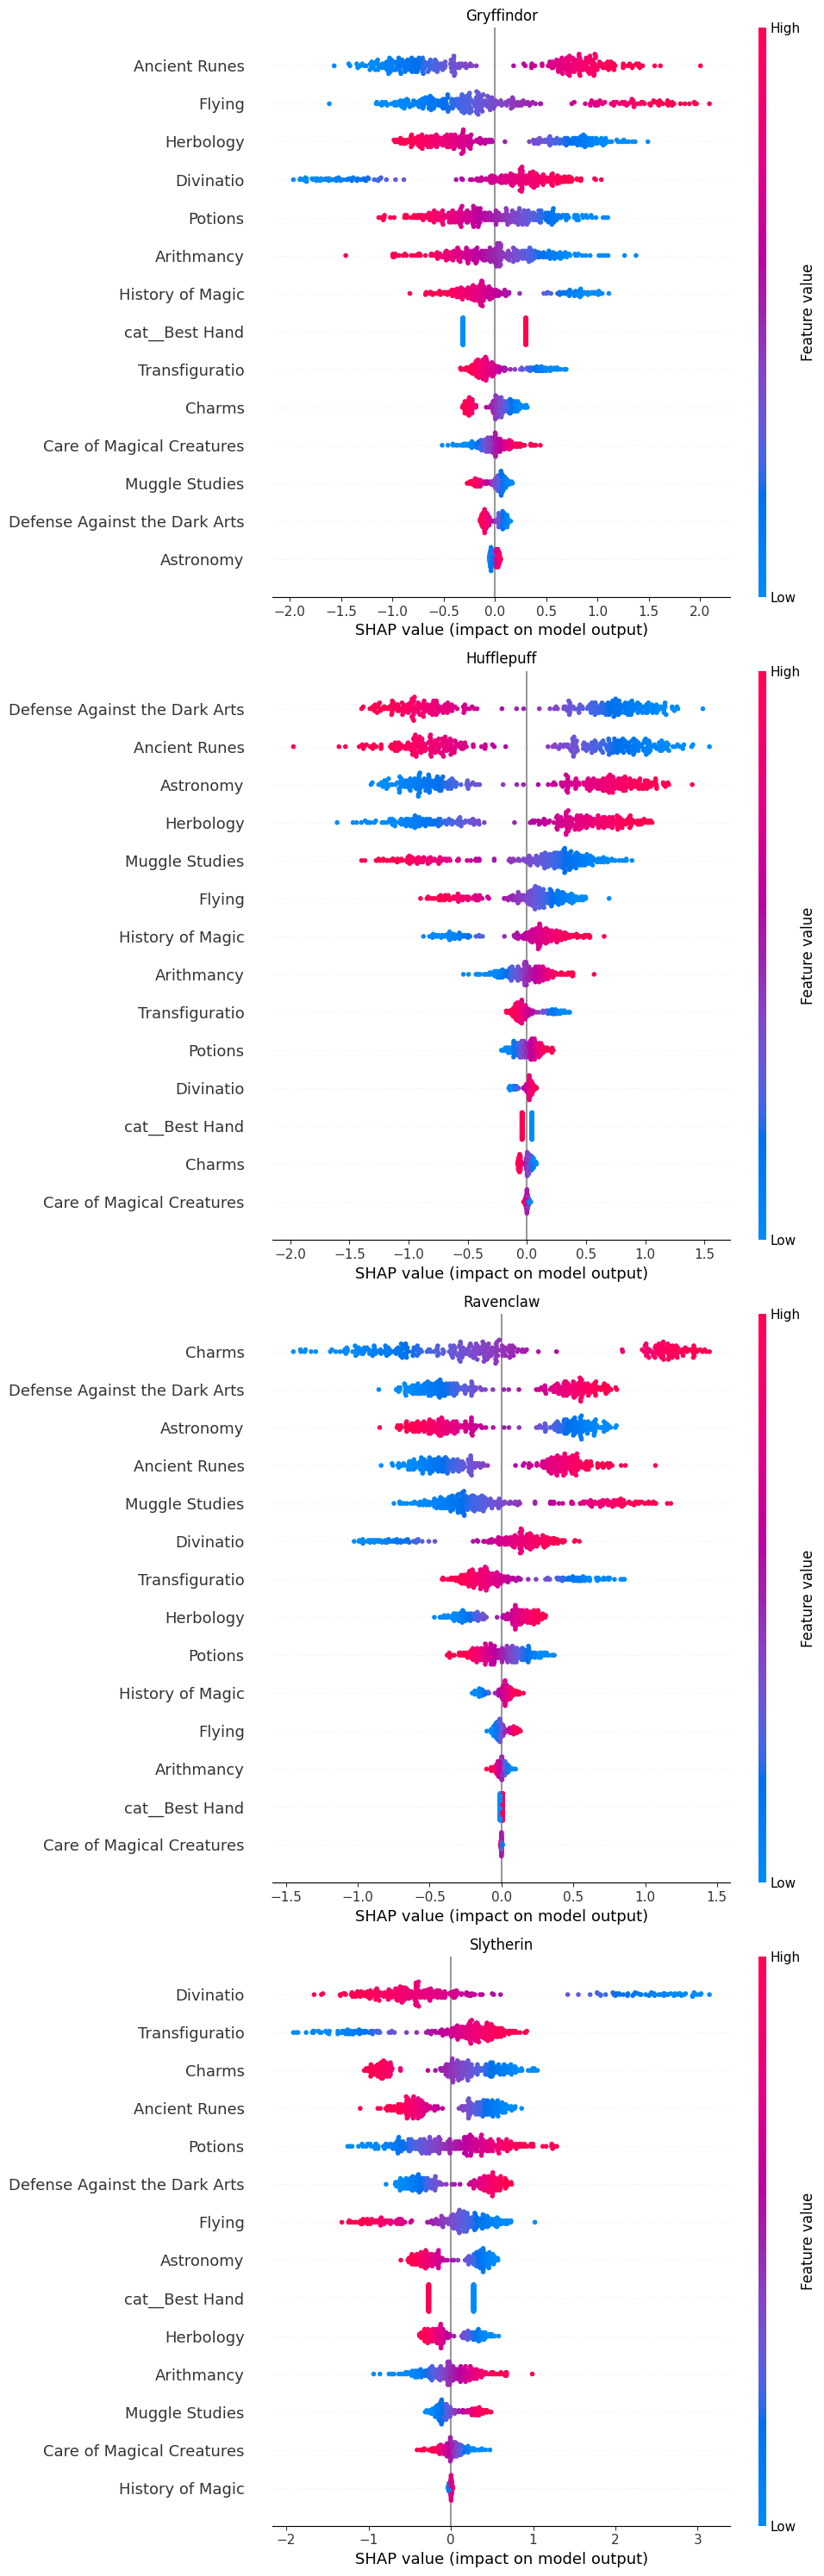

In [85]:
# explainability

import shap

features = preprocessor.get_feature_names_out()
features = [f.strip("num__") for f in features]


X_train_df = pd.DataFrame(X_train_proc, columns=features)
X_valid_df = pd.DataFrame(X_valid_proc, columns=features)



masker = shap.maskers.Independent(X_train_df, max_samples=len(X_train_df))

explainer = shap.LinearExplainer(lr, masker=masker)



shap_values = explainer.shap_values(X_valid_df)

fig, axes = plt.subplots(len(class_indices), figsize=(20, 6))

for i, cl in enumerate(class_indices):
    plt.sca(axes[i])
    shap.summary_plot(shap_values[:,:,i], X_valid_df, title=cl, show=False, plot_size=(10,30))
    plt.title(cl)

plt.show()